In [1]:
!pip install langchain

In [2]:
!pip install langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 4.4 MB/s eta 0:00:00


In [3]:
!pip install kagglehub[pandas-datasets]

In [4]:
# Import Environment & Langchain_openai
from langchain_openai import ChatOpenAI
from google.colab import userdata
api_key = userdata.get('OPEN_API_KEY')

# Define Model
llm = ChatOpenAI(model = 'gpt-4o-mini' \
                ,api_key = api_key)

# Part 1: Test GPT 4o-Mini

## Import First Data

In [5]:
import kagglehub

print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("abhi8923shriv/sentiment-analysis-dataset")
print("Download complete! File location:", path)

100%|██████████| 54.4M/54.4M [00:00<00:00, 158MB/s]

Extracting files...


Download complete! File location: /root/.cache/kagglehub/datasets/abhi8923shriv/sentiment-analysis-dataset/versions/9


In [7]:
import os

# ตรวจสอบว่ามีไฟล์อะไรอยู่ในโฟลเดอร์ที่ดาวน์โหลดมาบ้าง
print(os.listdir(path))

['testdata.manual.2009.06.14.csv', 'train.csv', 'test.csv', 'training.1600000.processed.noemoticon.csv']


In [8]:
import pandas as pd

# สร้าง full_path ไปยังไฟล์ CSV
csv_file_path = os.path.join(path, 'train.csv') # เปลี่ยนชื่อไฟล์ตามที่พบใน os.listdir(path)

# โหลดไฟล์ CSV เข้าสู่ DataFrame โดยระบุ encoding เป็น 'latin1'
df_sentiment = pd.read_csv(csv_file_path, encoding='latin1')

# แสดง 5 แถวแรกของ DataFrame
display(df_sentiment.head())

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [9]:
df_sentiment.shape

(27481, 10)

In [10]:
df_sentiment = df_sentiment.dropna(subset=['text', 'sentiment']).sample(n=1000, random_state=42)

df_sentiment.head(5)

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
1589,6c5505a37c,Enjoy! Family trumps everything,Enjoy! Family trumps everything,positive,night,70-100,Liechtenstein,38128,160.0,238
10414,126b1e6a22,--of them kinda turns me off of it all. And ...,kinda turns me off,negative,noon,60-70,Denmark,5792202,42430.0,137
6562,5bc4e623c4,Clive it`s my birthday pat me http://apps.fac...,Clive it`s my birthday pat me,neutral,noon,60-70,Israel,8655535,21640.0,400
2603,984d753104,congrats hey,congrats,positive,night,70-100,Bahamas,393244,10010.0,39
4004,8a79072ca2,is texting,is texting,neutral,night,31-45,Morocco,36910560,446300.0,83


## Deploy to first Data

In [11]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

In [12]:
# Test With DataSet 1

response = llm.invoke("""Please Categorize this text in parentheses (Clive it`s my birthday pat me) is
                        positive, negative or neutral. please answer 'positive',
                        'negative' or 'neutral' only
                      """)

print(response.content)

positive


In [13]:
response.response_metadata['token_usage']

{'completion_tokens': 1,
 'prompt_tokens': 49,
 'total_tokens': 50,
 'completion_tokens_details': {'accepted_prediction_tokens': 0,
  'audio_tokens': 0,
  'reasoning_tokens': 0,
  'rejected_prediction_tokens': 0},
 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}

In [14]:
print(response.response_metadata['token_usage']['completion_tokens'])
print(response.response_metadata['token_usage']['prompt_tokens'])

1
49


In [21]:
import time

predict = []
completion_tokens = []
prompt_token = []
count = 0
overall_start_time = time.time()

for text in df_sentiment['text']:
  response = llm.invoke(f"""Please Categorize this text in parentheses ({text}) is
                        positive, negative or neutral. please answer 'positive',
                        'negative' or 'neutral' only
                      """)

  predict.append(response.content)
  completion_tokens.append(response.response_metadata['token_usage']['completion_tokens'])
  prompt_token.append(response.response_metadata['token_usage']['prompt_tokens'])
  count = count+1
  print(f"Text number {count}. is categorized the answer is {response.content} , total completion usage {sum(completion_tokens)} and prompt is {sum(prompt_token)}")

total_duration = time.time() - overall_start_time
print(f"Finished! Total time: {total_duration/60:.2f} minutes")

Text number 1. is categorized the answer is positive , total completion usage 1 and prompt is 47
Text number 2. is categorized the answer is negative , total completion usage 2 and prompt is 116
Text number 3. is categorized the answer is positive , total completion usage 3 and prompt is 180
Text number 4. is categorized the answer is positive , total completion usage 4 and prompt is 224
Text number 5. is categorized the answer is neutral , total completion usage 5 and prompt is 267
Text number 6. is categorized the answer is neutral , total completion usage 6 and prompt is 331
Text number 7. is categorized the answer is neutral , total completion usage 7 and prompt is 375
Text number 8. is categorized the answer is negative , total completion usage 8 and prompt is 446
Text number 9. is categorized the answer is neutral , total completion usage 9 and prompt is 513
Text number 10. is categorized the answer is positive , total completion usage 10 and prompt is 561
Text number 11. is cate

In [23]:
df_sentiment['predicted_Openai'] = predict

df_sentiment.head(5)

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²),predicted_Openai
1589,6c5505a37c,Enjoy! Family trumps everything,Enjoy! Family trumps everything,positive,night,70-100,Liechtenstein,38128,160.0,238,positive
10414,126b1e6a22,--of them kinda turns me off of it all. And ...,kinda turns me off,negative,noon,60-70,Denmark,5792202,42430.0,137,negative
6562,5bc4e623c4,Clive it`s my birthday pat me http://apps.fac...,Clive it`s my birthday pat me,neutral,noon,60-70,Israel,8655535,21640.0,400,positive
2603,984d753104,congrats hey,congrats,positive,night,70-100,Bahamas,393244,10010.0,39,positive
4004,8a79072ca2,is texting,is texting,neutral,night,31-45,Morocco,36910560,446300.0,83,neutral


In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import seaborn as sns

In [30]:
# Evaluate results and plot Confusion Matrix
def evaluate_and_plot(true_labels, pred_labels, model_name):
    print(f"\n{'='*50}")
    print(f"Model Evaluation Results: {model_name}")
    print(f"{'='*50}")

    # Calculate Metrics
    acc = accuracy_score(true_labels, pred_labels)
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average='weighted', zero_division=0)

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f} (Weighted)")
    print(f"Recall:    {recall:.4f} (Weighted)")
    print(f"F1 Score:  {f1:.4f} (Weighted)")

    print("\nClassification Report:")
    print(classification_report(true_labels, pred_labels, target_names=['Negative', 'Neutral', 'Positive'], zero_division=0))

    # Plot Confusion Matrix
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual (True)')
    plt.show()


Model Evaluation Results: Open AI 4o Mini
Accuracy:  0.6410
Precision: 0.6447 (Weighted)
Recall:    0.6410 (Weighted)
F1 Score:  0.6183 (Weighted)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.68      0.81      0.74       281
     Neutral       0.65      0.36      0.46       393
    Positive       0.61      0.84      0.71       326

    accuracy                           0.64      1000
   macro avg       0.65      0.67      0.63      1000
weighted avg       0.64      0.64      0.62      1000



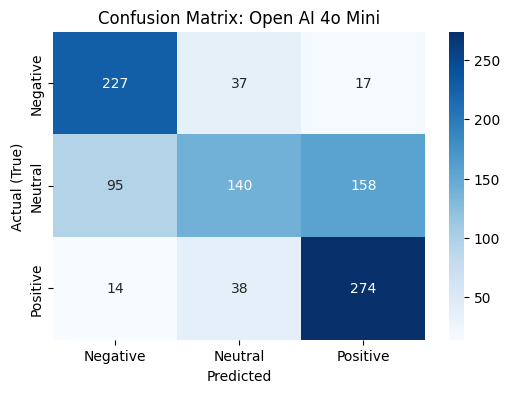

In [31]:
# Call the evaluation function for each model
evaluate_and_plot(df_sentiment['sentiment'], df_sentiment['predicted_Openai'], "Open AI 4o Mini")

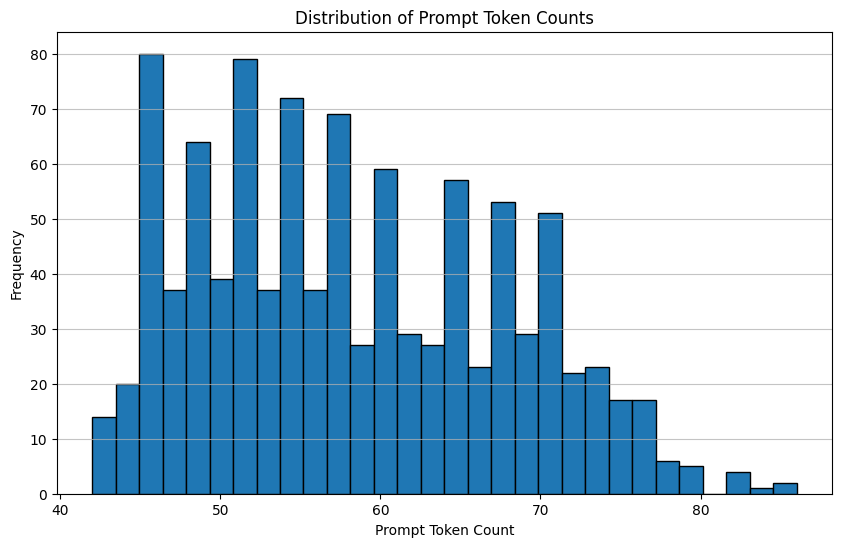

In [40]:
# Prompt Token Usage
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(prompt_token, bins=30, edgecolor='black')
plt.title('Distribution of Prompt Token Counts')
plt.xlabel('Prompt Token Count')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [42]:
mean = sum(prompt_token) / len(prompt_token)
print("Mean:", mean)

Mean: 58.225


## Import New Dataset

In [32]:
print("\n===== Downloading New Dataset =====")
new_dataset_path = kagglehub.dataset_download("abdelmalekeladjelet/sentiment-analysis-dataset")
print("New Dataset download complete! File location:", new_dataset_path)


===== Downloading New Dataset =====


100%|██████████| 8.68M/8.68M [00:00<00:00, 41.7MB/s]

Extracting files...


New Dataset download complete! File location: /root/.cache/kagglehub/datasets/abdelmalekeladjelet/sentiment-analysis-dataset/versions/1


In [34]:
import os

# ตรวจสอบว่ามีไฟล์อะไรอยู่ในโฟลเดอร์ที่ดาวน์โหลดมาบ้าง
print(os.listdir(new_dataset_path))

['sentiment_data.csv']


In [36]:
import pandas as pd

# สร้าง full_path ไปยังไฟล์ CSV
csv_file_path = os.path.join(new_dataset_path, 'sentiment_data.csv') # เปลี่ยนชื่อไฟล์ตามที่พบใน os.listdir(path)

# โหลดไฟล์ CSV เข้าสู่ DataFrame โดยระบุ encoding เป็น 'latin1'
df_sentiment_2 = pd.read_csv(csv_file_path, encoding='latin1')

# แสดง 5 แถวแรกของ DataFrame
display(df_sentiment_2.head())

,Unnamed: 0,Comment,Sentiment
0,0,lets forget apple pay required brand new iphon...,1
1,1,nz retailers donât even contactless credit c...,0
2,2,forever acknowledge channel help lessons ideas...,2
3,3,whenever go place doesnât take apple pay doe...,0
4,4,apple pay convenient secure easy use used kore...,2


In [37]:
df_sentiment_2.shape

(241145, 3)

In [39]:
df_sentiment_2 = df_sentiment_2.dropna(subset=['Comment', 'Sentiment']).sample(n=1000, random_state=42)

df_sentiment_2.head(5)

,Unnamed: 0,Comment,Sentiment
138371,139149,indian giving message country going ahead new ...,2
93134,93912,hating modi trend loom replies instant famous,2
99587,100365,hahaha modi khauff stronger sibling rivalries,2
167512,168290,watch official trailer modi subscribe erosnow ...,1
82026,82804,called concern poor modi bjp doesnt poor count...,0


## Deploy to new data

In [43]:
import time

predict = []
completion_tokens = []
prompt_token = []
count = 0
overall_start_time = time.time()

for text in df_sentiment_2['Comment']:
  response = llm.invoke(f"""Please Categorize this text in parentheses ({text}) is
                        positive, negative or neutral. please answer 'positive',
                        'negative' or 'neutral' only
                      """)

  predict.append(response.content)
  completion_tokens.append(response.response_metadata['token_usage']['completion_tokens'])
  prompt_token.append(response.response_metadata['token_usage']['prompt_tokens'])
  count = count+1
  print(f"Text number {count}. is categorized the answer is {response.content} , total completion usage {sum(completion_tokens)} and prompt is {sum(prompt_token)}")

total_duration = time.time() - overall_start_time
print(f"Finished! Total time: {total_duration/60:.2f} minutes")

Text number 1. is categorized the answer is positive , total completion usage 1 and prompt is 66
Text number 2. is categorized the answer is negative , total completion usage 2 and prompt is 115
Text number 3. is categorized the answer is negative , total completion usage 3 and prompt is 165
Text number 4. is categorized the answer is positive , total completion usage 4 and prompt is 217
Text number 5. is categorized the answer is negative , total completion usage 5 and prompt is 272
Text number 6. is categorized the answer is negative , total completion usage 6 and prompt is 339
Text number 7. is categorized the answer is negative , total completion usage 7 and prompt is 388
Text number 8. is categorized the answer is negative , total completion usage 8 and prompt is 438
Text number 9. is categorized the answer is positive , total completion usage 9 and prompt is 481
Text number 10. is categorized the answer is positive , total completion usage 10 and prompt is 532
Text number 11. is 

In [45]:
df_sentiment_2['predicted_Openai'] = predict

df_sentiment_2.head(5)

,Unnamed: 0,Comment,Sentiment,predicted_Openai
138371,139149,indian giving message country going ahead new ...,2,positive
93134,93912,hating modi trend loom replies instant famous,2,negative
99587,100365,hahaha modi khauff stronger sibling rivalries,2,negative
167512,168290,watch official trailer modi subscribe erosnow ...,1,positive
82026,82804,called concern poor modi bjp doesnt poor count...,0,negative


In [48]:
def encode_true_label(label):
    label = str(label).strip().lower()
    if label in ['negative', 'neg', '0']: return 0
    elif label in ['neutral', 'neu', '1']: return 1
    else: return 2

In [49]:
df_sentiment_2['predicted_Openai'] = df_sentiment_2['predicted_Openai'].apply(encode_true_label)

df_sentiment_2.head()

,Unnamed: 0,Comment,Sentiment,predicted_Openai
138371,139149,indian giving message country going ahead new ...,2,2
93134,93912,hating modi trend loom replies instant famous,2,0
99587,100365,hahaha modi khauff stronger sibling rivalries,2,0
167512,168290,watch official trailer modi subscribe erosnow ...,1,2
82026,82804,called concern poor modi bjp doesnt poor count...,0,0



Model Evaluation Results: Open AI 4o Mini - New Data Set
Accuracy:  0.5050
Precision: 0.5842 (Weighted)
Recall:    0.5050 (Weighted)
F1 Score:  0.5098 (Weighted)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.35      0.77      0.48       219
     Neutral       0.58      0.39      0.47       349
    Positive       0.70      0.47      0.56       432

    accuracy                           0.51      1000
   macro avg       0.55      0.54      0.50      1000
weighted avg       0.58      0.51      0.51      1000



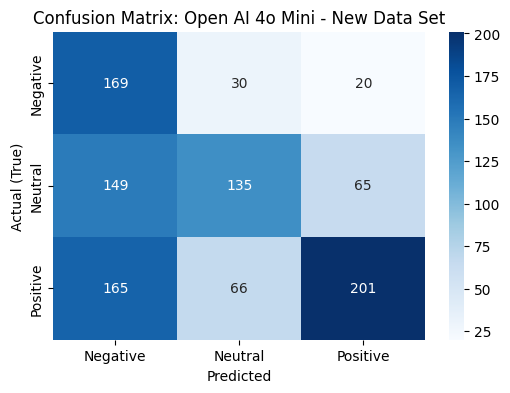

In [50]:
# Call the evaluation function for each model
evaluate_and_plot(df_sentiment_2['Sentiment'], df_sentiment_2['predicted_Openai'], "Open AI 4o Mini - New Data Set")

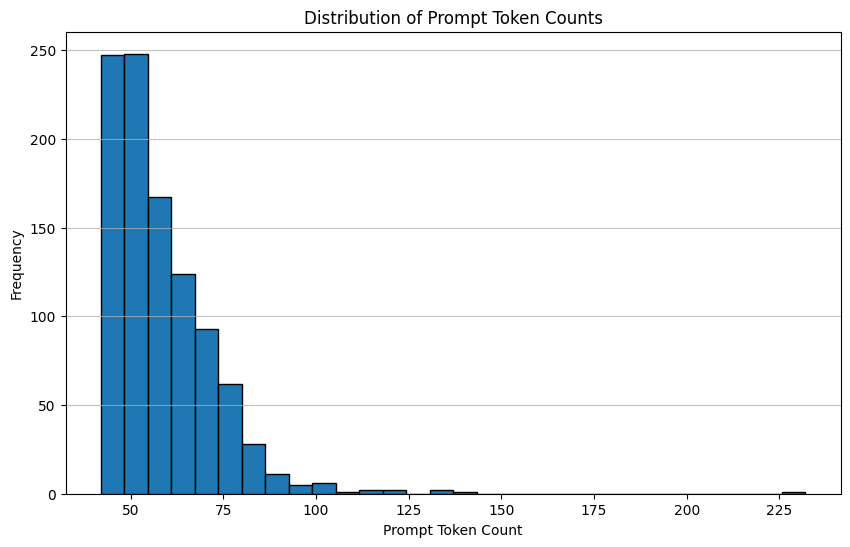

In [51]:
# Prompt Token Usage
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(prompt_token, bins=30, edgecolor='black')
plt.title('Distribution of Prompt Token Counts')
plt.xlabel('Prompt Token Count')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [52]:
mean = sum(prompt_token) / len(prompt_token)
print("Mean:", mean)

Mean: 58.395


# Test GPT 5.4 nano

In [53]:
# Define Model
llm = ChatOpenAI(model = 'gpt-5.4-nano' \
                ,api_key = api_key)

In [54]:
df_sentiment.head(5)

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²),predicted_Openai
1589,6c5505a37c,Enjoy! Family trumps everything,Enjoy! Family trumps everything,positive,night,70-100,Liechtenstein,38128,160.0,238,positive
10414,126b1e6a22,--of them kinda turns me off of it all. And ...,kinda turns me off,negative,noon,60-70,Denmark,5792202,42430.0,137,negative
6562,5bc4e623c4,Clive it`s my birthday pat me http://apps.fac...,Clive it`s my birthday pat me,neutral,noon,60-70,Israel,8655535,21640.0,400,positive
2603,984d753104,congrats hey,congrats,positive,night,70-100,Bahamas,393244,10010.0,39,positive
4004,8a79072ca2,is texting,is texting,neutral,night,31-45,Morocco,36910560,446300.0,83,neutral


In [68]:
import time
import numpy as np

predict = []
completion_tokens = []
prompt_token = []
count = 0
overall_start_time = time.time()

for text in df_sentiment['text']:
    count = count + 1 # ย้าย count มาไว้ตรงนี้เพื่อให้รันลำดับได้ถูกต้องแม้เกิด Error

    try:
        response = llm.invoke(f"""Please Categorize this text in parentheses ({text}) is
                                positive, negative or neutral. please answer 'positive',
                                'negative' or 'neutral' only
                              """)

        predict.append(response.content)
        completion_tokens.append(response.response_metadata['token_usage']['completion_tokens'])
        prompt_token.append(response.response_metadata['token_usage']['prompt_tokens'])

        print(f"Text number {count}. is categorized the answer is {response.content} , total completion usage {sum(completion_tokens)} and prompt is {sum(prompt_token)}")

    except Exception as e:
        # กรณีเกิด Error ให้เก็บค่า Error ลงไปแทน เพื่อรักษาความยาวของ List ให้เท่ากับ DataFrame
        predict.append(np.nan)
        completion_tokens.append(0) # ให้ token เป็น 0 เพราะไม่ได้ใช้งานจริง
        prompt_token.append(0)

        # ปริ้นท์บอกว่าข้อความที่เท่าไหร่พัง และข้ามไป
        print(f"Text number {count}. encountered an ERROR -> Skipped.")
        continue # สั่งให้ไปลูปถัดไปทันที

total_duration = time.time() - overall_start_time
print(f"Finished! Total time: {total_duration/60:.2f} minutes")

Text number 1. is categorized the answer is positive , total completion usage 4 and prompt is 46
Text number 2. is categorized the answer is negative , total completion usage 8 and prompt is 114
Text number 3. is categorized the answer is positive , total completion usage 12 and prompt is 177
Text number 4. is categorized the answer is positive , total completion usage 16 and prompt is 220
Text number 5. is categorized the answer is Please paste the text you want categorized (inside the parentheses). , total completion usage 31 and prompt is 262
Text number 6. is categorized the answer is neutral , total completion usage 35 and prompt is 325
Text number 7. is categorized the answer is neutral , total completion usage 39 and prompt is 368
Text number 8. is categorized the answer is negative , total completion usage 43 and prompt is 438
Text number 9. is categorized the answer is positive , total completion usage 47 and prompt is 504
Text number 10. is categorized the answer is neutral ,

In [69]:
df_sentiment['predicted_OpenAI_5.4-nano'] = predict

df_sentiment.head(5)

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²),predicted_Openai,predicted_OpenAI_5.4-nano
1589,6c5505a37c,Enjoy! Family trumps everything,Enjoy! Family trumps everything,positive,night,70-100,Liechtenstein,38128,160.0,238,positive,positive
10414,126b1e6a22,--of them kinda turns me off of it all. And ...,kinda turns me off,negative,noon,60-70,Denmark,5792202,42430.0,137,negative,negative
6562,5bc4e623c4,Clive it`s my birthday pat me http://apps.fac...,Clive it`s my birthday pat me,neutral,noon,60-70,Israel,8655535,21640.0,400,positive,positive
2603,984d753104,congrats hey,congrats,positive,night,70-100,Bahamas,393244,10010.0,39,positive,positive
4004,8a79072ca2,is texting,is texting,neutral,night,31-45,Morocco,36910560,446300.0,83,neutral,Please paste the text you want categorized (in...


In [70]:
df_sentiment = df_sentiment[df_sentiment['predicted_OpenAI_5.4-nano'].isin(['positive', 'negative', 'neutral'])]
df_sentiment.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²),predicted_Openai,predicted_OpenAI_5.4-nano
1589,6c5505a37c,Enjoy! Family trumps everything,Enjoy! Family trumps everything,positive,night,70-100,Liechtenstein,38128,160.0,238,positive,positive
10414,126b1e6a22,--of them kinda turns me off of it all. And ...,kinda turns me off,negative,noon,60-70,Denmark,5792202,42430.0,137,negative,negative
6562,5bc4e623c4,Clive it`s my birthday pat me http://apps.fac...,Clive it`s my birthday pat me,neutral,noon,60-70,Israel,8655535,21640.0,400,positive,positive
2603,984d753104,congrats hey,congrats,positive,night,70-100,Bahamas,393244,10010.0,39,positive,positive
1570,de46775458,Do you have any idea when the (not so) patien...,Do you have any idea when the (not so) patient...,neutral,noon,60-70,Iran,83992949,1630000.0,52,neutral,neutral


In [71]:
df_sentiment.shape

(994, 12)


Model Evaluation Results: Open AI 5.4 Nano
Accuracy:  0.6107
Precision: 0.6154 (Weighted)
Recall:    0.6107 (Weighted)
F1 Score:  0.5957 (Weighted)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.65      0.67      0.66       281
     Neutral       0.62      0.39      0.48       389
    Positive       0.58      0.83      0.68       324

    accuracy                           0.61       994
   macro avg       0.62      0.63      0.61       994
weighted avg       0.62      0.61      0.60       994



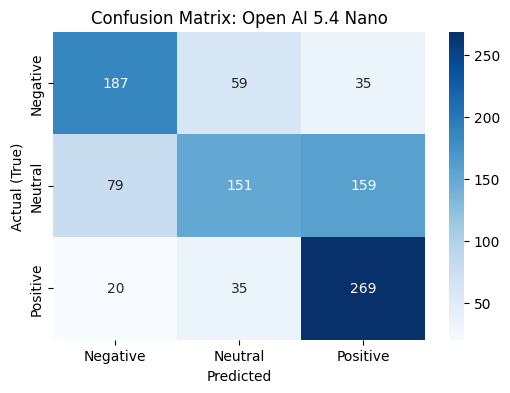

In [72]:
# Call the evaluation function for each model
evaluate_and_plot(df_sentiment['sentiment'], df_sentiment['predicted_OpenAI_5.4-nano'], "Open AI 5.4 Nano")

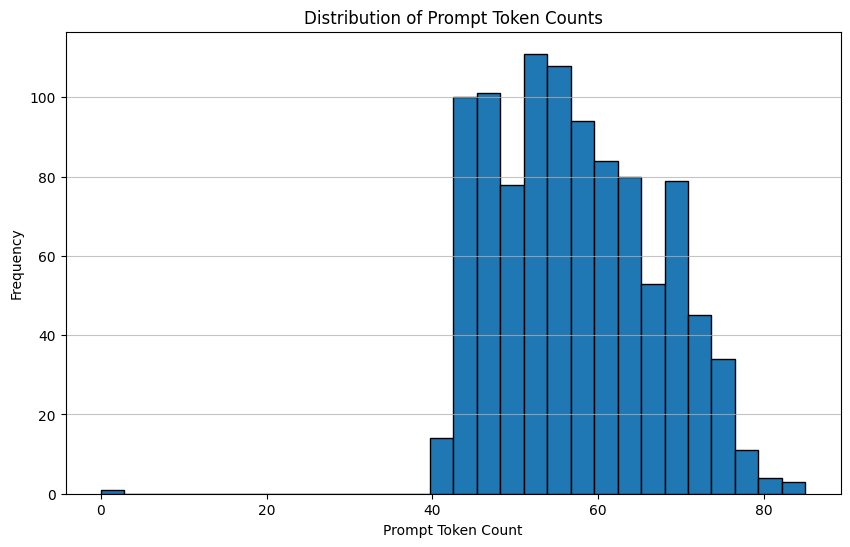

In [74]:
# Prompt Token Usage
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(prompt_token, bins=30, edgecolor='black')
plt.title('Distribution of Prompt Token Counts')
plt.xlabel('Prompt Token Count')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## New Data

In [73]:
df_sentiment_2.head(5)

,Unnamed: 0,Comment,Sentiment,predicted_Openai
138371,139149,indian giving message country going ahead new ...,2,2
93134,93912,hating modi trend loom replies instant famous,2,0
99587,100365,hahaha modi khauff stronger sibling rivalries,2,0
167512,168290,watch official trailer modi subscribe erosnow ...,1,2
82026,82804,called concern poor modi bjp doesnt poor count...,0,0


In [75]:
import time
import numpy as np

predict = []
completion_tokens = []
prompt_token = []
count = 0
overall_start_time = time.time()

for text in df_sentiment_2['Comment']:
    count = count + 1 # ย้าย count มาไว้ตรงนี้เพื่อให้รันลำดับได้ถูกต้องแม้เกิด Error

    try:
        response = llm.invoke(f"""Please Categorize this text in parentheses ({text}) is
                                positive, negative or neutral. please answer 'positive',
                                'negative' or 'neutral' only
                              """)

        predict.append(response.content)
        completion_tokens.append(response.response_metadata['token_usage']['completion_tokens'])
        prompt_token.append(response.response_metadata['token_usage']['prompt_tokens'])

        print(f"Text number {count}. is categorized the answer is {response.content} , total completion usage {sum(completion_tokens)} and prompt is {sum(prompt_token)}")

    except Exception as e:
        # กรณีเกิด Error ให้เก็บค่า Error ลงไปแทน เพื่อรักษาความยาวของ List ให้เท่ากับ DataFrame
        predict.append(np.nan)
        completion_tokens.append(0) # ให้ token เป็น 0 เพราะไม่ได้ใช้งานจริง
        prompt_token.append(0)

        # ปริ้นท์บอกว่าข้อความที่เท่าไหร่พัง และข้ามไป
        print(f"Text number {count}. encountered an ERROR -> Skipped.")
        continue # สั่งให้ไปลูปถัดไปทันที

total_duration = time.time() - overall_start_time
print(f"Finished! Total time: {total_duration/60:.2f} minutes")

Text number 1. is categorized the answer is positive , total completion usage 4 and prompt is 65
Text number 2. is categorized the answer is negative , total completion usage 8 and prompt is 113
Text number 3. is categorized the answer is negative , total completion usage 12 and prompt is 162
Text number 4. is categorized the answer is neutral , total completion usage 16 and prompt is 213
Text number 5. is categorized the answer is neutral , total completion usage 20 and prompt is 267
Text number 6. is categorized the answer is negative , total completion usage 24 and prompt is 333
Text number 7. is categorized the answer is negative , total completion usage 28 and prompt is 381
Text number 8. is categorized the answer is negative , total completion usage 32 and prompt is 430
Text number 9. is categorized the answer is positive , total completion usage 36 and prompt is 472
Text number 10. is categorized the answer is positive , total completion usage 40 and prompt is 522
Text number 11

In [76]:
df_sentiment_2['predicted_OpenAI_5.4-nano'] = predict

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²),predicted_Openai,predicted_OpenAI_5.4-nano
1589,6c5505a37c,Enjoy! Family trumps everything,Enjoy! Family trumps everything,positive,night,70-100,Liechtenstein,38128,160.0,238,positive,positive
10414,126b1e6a22,--of them kinda turns me off of it all. And ...,kinda turns me off,negative,noon,60-70,Denmark,5792202,42430.0,137,negative,negative
6562,5bc4e623c4,Clive it`s my birthday pat me http://apps.fac...,Clive it`s my birthday pat me,neutral,noon,60-70,Israel,8655535,21640.0,400,positive,positive
2603,984d753104,congrats hey,congrats,positive,night,70-100,Bahamas,393244,10010.0,39,positive,positive
1570,de46775458,Do you have any idea when the (not so) patien...,Do you have any idea when the (not so) patient...,neutral,noon,60-70,Iran,83992949,1630000.0,52,neutral,neutral


In [77]:
df_sentiment_2.head(5)

,Unnamed: 0,Comment,Sentiment,predicted_Openai,predicted_OpenAI_5.4-nano
138371,139149,indian giving message country going ahead new ...,2,2,positive
93134,93912,hating modi trend loom replies instant famous,2,0,negative
99587,100365,hahaha modi khauff stronger sibling rivalries,2,0,negative
167512,168290,watch official trailer modi subscribe erosnow ...,1,2,neutral
82026,82804,called concern poor modi bjp doesnt poor count...,0,0,neutral


In [79]:
df_sentiment_2 = df_sentiment_2[df_sentiment_2['predicted_OpenAI_5.4-nano'].isin(['positive', 'negative', 'neutral'])]
df_sentiment_2.head()

,Unnamed: 0,Comment,Sentiment,predicted_Openai,predicted_OpenAI_5.4-nano
138371,139149,indian giving message country going ahead new ...,2,2,positive
93134,93912,hating modi trend loom replies instant famous,2,0,negative
99587,100365,hahaha modi khauff stronger sibling rivalries,2,0,negative
167512,168290,watch official trailer modi subscribe erosnow ...,1,2,neutral
82026,82804,called concern poor modi bjp doesnt poor count...,0,0,neutral


In [80]:
df_sentiment_2['predicted_OpenAI_5.4-nano'] = df_sentiment_2['predicted_OpenAI_5.4-nano'].apply(encode_true_label)

df_sentiment_2.head()

/tmp/ipykernel_4300/3618319233.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sentiment_2['predicted_OpenAI_5.4-nano'] = df_sentiment_2['predicted_OpenAI_5.4-nano'].apply(encode_true_label)


,Unnamed: 0,Comment,Sentiment,predicted_Openai,predicted_OpenAI_5.4-nano
138371,139149,indian giving message country going ahead new ...,2,2,2
93134,93912,hating modi trend loom replies instant famous,2,0,0
99587,100365,hahaha modi khauff stronger sibling rivalries,2,0,0
167512,168290,watch official trailer modi subscribe erosnow ...,1,2,1
82026,82804,called concern poor modi bjp doesnt poor count...,0,0,1



Model Evaluation Results: Open AI 5.4 Nano - New Data Set
Accuracy:  0.4934
Precision: 0.5269 (Weighted)
Recall:    0.4934 (Weighted)
F1 Score:  0.4960 (Weighted)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.38      0.51      0.44       218
     Neutral       0.47      0.57      0.52       336
    Positive       0.65      0.42      0.51       429

    accuracy                           0.49       983
   macro avg       0.50      0.50      0.49       983
weighted avg       0.53      0.49      0.50       983



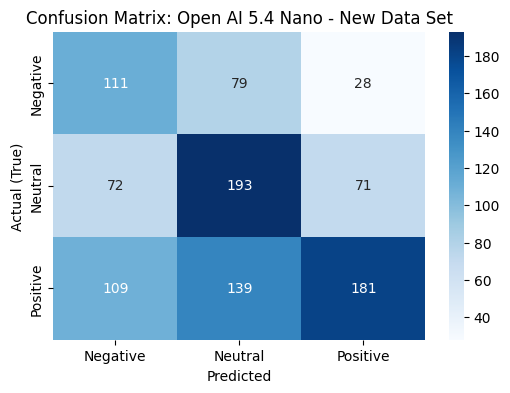

In [81]:
# Call the evaluation function for each model
evaluate_and_plot(df_sentiment_2['Sentiment'], df_sentiment_2['predicted_OpenAI_5.4-nano'], "Open AI 5.4 Nano - New Data Set")

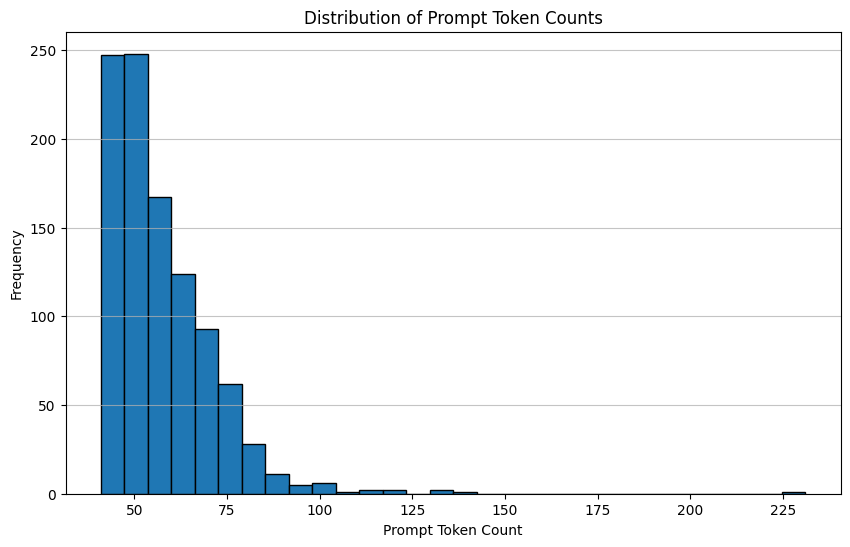

In [82]:
# Prompt Token Usage
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(prompt_token, bins=30, edgecolor='black')
plt.title('Distribution of Prompt Token Counts')
plt.xlabel('Prompt Token Count')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()